In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tqdm, utils, theory, data
from tabulate import tabulate
from numpy.linalg import inv as inv

%load_ext autoreload
%autoreload 2

P = 1000
P_test = 100
n_tasks = 2
T = 0
sigma = 0.2
depth = 10
lamb = 10000000

n_seeds = 1

loss12 = []
loss13 = []

n_epochs = 1
permutation = True
dataset = 'cifar'

fixed_w = True

depths = np.arange(1, 11)
pred_loss = np.zeros((n_seeds, 10, len(depths)))
factors = np.zeros((n_seeds, 10, len(depths)))
pred_loss2 = np.zeros((n_seeds, 10, len(depths)))
pred_loss3 = np.zeros((n_seeds, 10, len(depths)))


for SEED in tqdm.trange(n_seeds):

    np.random.seed(SEED)

    seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit =\
        data.prepare_sequential_dataset(n_tasks, P, P_test,
                                        dataset_name=dataset, resample=True, permutation=permutation)


    seq_of_train_y_onehot = [data.digit_to_onehot(_target) for _target in seq_of_train_y_digit]

    inv_mats = np.zeros((len(depths), P, P))
    inv_mats2 = np.zeros((len(depths), P, P))
    inv_mats3 =np.zeros((len(depths), P, P))

    for i in range(len(depths)):
        _depth = depths[i]
        K = np.zeros((n_tasks, n_tasks, P, P))
        for t in range(n_tasks):
            for t_prime in range(n_tasks):
                K[t, t_prime] = theory.arccos_kernel_deep(seq_of_train_x[t], seq_of_train_x[t_prime], var1=1, depth=_depth + 1)
        inv_mats[i] = (K[0,0] - K[0,1] @ inv(K[1,1]) @ K[1,0]) @ inv(K[0,0])
        # inv_mats2[i] = (K[0,0] - K[0,1] @ inv(K[1,1]) @ K[1,0] -
        #                 K[0,2] @ inv(K[2,2]) @ K[2,0] +
        #                 K[0,2] @ inv(K[2,2]) @ K[2,1].T @ inv(K[1,1]) @ K[1,0]) @ inv(K[0,0])
        # inv_mats3[i] = (K[0,0] - K[0,1] @ inv(K[1,1]) @ K[1,0] -
        #                 K[0,2] @ inv(K[2,2]) @ K[2,0] -
        #                 K[0,3] @ inv(K[3,3]) @ K[3,0] +
        #                 K[0,2] @ inv(K[2,2]) @ K[2,1].T @ inv(K[1,1]) @ K[1,0] +
        #                 K[0,3] @ inv(K[3,3]) @ K[3,2].T @ inv(K[2,2]) @ K[2,0] +
        #                 K[0,3] @ inv(K[3,3]) @ K[3,1].T @ inv(K[1,1]) @ K[1,0] -
        #                 K[0,3] @ inv(K[3,3]) @ K[3,2].T @ inv(K[2,2]) @ K[2,1] @ inv(K[1,1]) @ K[1,0]) @ inv(K[0,0])

    for head_ind in range(10):
        y1 = seq_of_train_y_onehot[0][:, head_ind, :]
        for i in range(len(depths)):
            _depth = depths[i]
            pred_loss[SEED, head_ind, i] = (np.linalg.norm(y1)**2 - y1.T @ inv_mats[i] @ y1) / P * 2
            pred_loss2[SEED, head_ind, i] = (np.linalg.norm(y1)**2 - y1.T @ inv_mats2[i] @ y1) / P * 2
            pred_loss3[SEED, head_ind, i] = (np.linalg.norm(y1)**2 - y1.T @ inv_mats3[i] @ y1) / P * 2
            factors[SEED, head_ind, i] =\
                float(y1.T @ (np.eye(P) - inv_mats[i]) @ y1 / np.linalg.norm(y1)**2)


    # these objects have shape num_tasks * P/P_test * dim


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


  0%|          | 0/1 [00:00<?, ?it/s]

Files already downloaded and verified
Files already downloaded and verified


100%|██████████| 1/1 [00:12<00:00, 12.09s/it]


In [6]:
seq_of_train_x, seq_of_test_x, seq_of_train_y_digit, seq_of_test_y_digit =\
    data.prepare_sequential_dataset(n_tasks, P, P_test,
                                    dataset_name=dataset, resample=True, permutation=permutation)

self_ks = []
cross_ks = []
for i in range(10):
    self_ks.append(theory.arccos_kernel_deep(seq_of_train_x[0],
                                             seq_of_train_x[0],
                                             var1=1, depth=i+1))
    cross_ks.append(theory.arccos_kernel_deep(seq_of_train_x[0],
                                             seq_of_train_x[1],
                                             var1=1, depth=i+1))

Files already downloaded and verified
Files already downloaded and verified


In [7]:
cos_within_set = []
cos_cross_set = []

for i in range(10):
    cos_within_set.append(np.mean(self_ks[i] / np.sqrt(np.diag(self_ks[i]).reshape(-1, 1) @ np.diag(self_ks[i]).reshape(1, -1))))
    cos_cross_set.append(np.mean(cross_ks[i] / np.sqrt(np.diag(self_ks[i]).reshape(-1, 1) @ np.diag(self_ks[i]).reshape(1, -1))))

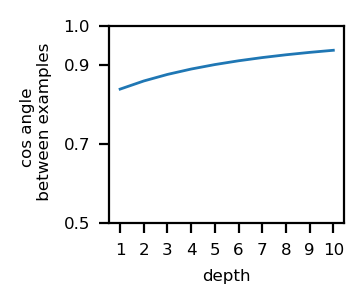

In [8]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = [1.8, 1.5]
plt.rcParams.update({'font.size': 6})
plt.rcParams['lines.linewidth'] = 1

plt.figure()
# plt.plot(np.arange(10) + 1, cos_cross_set, label='different permutation')
plt.plot(np.arange(10) + 1, cos_within_set, label='same permutation')
plt.yticks([0.5, 0.7, 0.9, 1.0])
plt.xticks(np.arange(1, 11))
plt.xlabel('depth')
plt.ylabel('cos angle \n between examples')
# plt.legend()
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel2.svg')

In [14]:
factors.shape

(5, 10, 10)

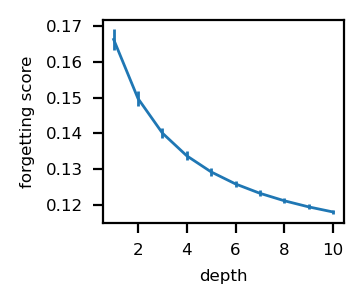

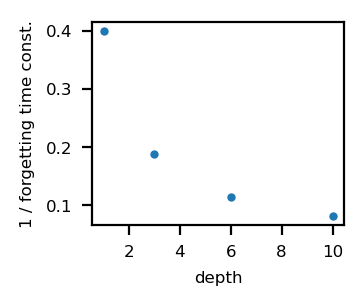

In [30]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = [1.8, 1.5]
plt.rcParams.update({'font.size': 6})
plt.rcParams['lines.linewidth'] = 1

plt.figure()
plt.errorbar(depths, factors.mean(1).mean(0), factors.mean(1).std(0))
plt.xlabel('depth')
plt.ylabel('forgetting score')
plt.xticks([2, 4, 6, 8, 10])
plt.tight_layout()
# plt.title('Definition: $1 - y^T X_1(I-P_2)X_1^T K_1^{-1} y/y^Ty$')
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')


plt.figure()
plt.scatter([1, 3, 6, 10], 1 / np.array([2.5, 5.3, 8.7, 12.3]), s=4)
plt.xlabel('depth')
plt.ylabel('1 / forgetting time const.')
plt.tight_layout()
plt.savefig('/Users/haozheshan/Dropbox/codes/gp_continual_learning/figures/' + 'panel.svg')
# plt.suptitle('Definition: L(t)=asympt. + (init - asympt). x e^{-t/tau}')

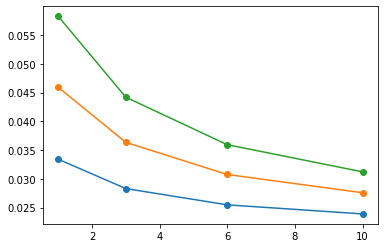

In [25]:


plt.figure()
plt.plot(depths, pred_loss.mean(0).mean(0), marker='o')
plt.plot(depths, pred_loss2.mean(0).mean(0), marker='o')
plt.plot(depths, pred_loss3.mean(0).mean(0), marker='o')
# plt.plot(np.arange(1, 11), traces2 / P * 2, marker='o')